In [ ]:
import numpy as np
import scipy.signal as signal
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def get_psds(f, fc, fs, snr_linear):
    """
    Generates the Turbulence and Noise PSDs.
    Turbulence is flat up to fc, then falls as f^(-17/3).
    """
    # 1. Turbulence PSD
    psd_turb = np.ones_like(f)
    mask = f > fc
    psd_turb[mask] = (f[mask] / fc)**(-17/3)
    
    # Normalize turbulence variance to 1.0 for reference
    df = f[1] - f[0]
    var_turb = np.sum(psd_turb) * df
    psd_turb /= var_turb
    
    # 2. Measurement Noise PSD (White noise assumption)
    # SNR = Var(Turbulence) / Var(Noise)
    var_noise = 1.0 / snr_linear
    psd_noise = np.ones_like(f) * (var_noise / (fs / 2))
    
    return psd_turb, psd_noise

def evaluate_controller(params, num_zeros, num_poles, f, fs, N_delay, psd_turb, psd_noise, return_details=False):
    """
    Evaluates the residual variance for a given digital controller.
    """
    # Extract coefficients (scipy uses 'b' for numerator/zeros, 'a' for denominator/poles)
    b = params[:num_zeros+1]
    a = np.concatenate(([1.0], params[num_poles+1:]))
    
    # 1. Controller Frequency Response
    w = 2 * np.pi * f / fs
    with np.errstate(divide='ignore', invalid='ignore'):
        _, C = signal.freqz(b, a, worN=w)
        
    # 2. Plant Frequency Response: Pure Fractional Delay
    P = np.exp(-1j * 2 * np.pi * (f / fs) * N_delay)
    
    # 3. Open Loop
    H_open = P * C
    
    # 4. Error Rejection (RTF) and Noise Transfer Functions (NTF)
    RTF = 1.0 / (1.0 + H_open)
    NTF = H_open / (1.0 + H_open)
        
    # 5. Residual PSD and Variance
    psd_res = (np.abs(RTF)**2) * (psd_turb+psd_noise) #+ (np.abs(NTF)**2) * psd_noise
    df = f[1] - f[0]
    variance = np.sum(psd_res) * df
    
    # 6. Stability Constraints (Modulus Margin)
    # The Nyquist contour must not get dangerously close to the -1 point.
    modulus_margin = np.min(np.abs(1.0 + H_open[1:]))
    penalty = 0.0
    
    # Enforce robustness margin (e.g., minimum distance of 0.3 to critical point)
    if modulus_margin < 0.1:
        penalty += 1e6 * (0.1 - modulus_margin)
        
    # Open-loop controller stability check
    roots_a = np.roots(a)
    if np.any(np.abs(roots_a) > 1.001): # allow integrator at 1.0
        penalty += 1e7
        
    if return_details:
        return variance, psd_res, np.abs(RTF)**2, np.abs(NTF)**2
    return variance + penalty

def optimize_controller(order_zeros, order_poles, f, fs, N_delay, psd_turb, psd_noise):
    """
    Finds optimal filter coefficients using Nelder-Mead to handle the stability penalties.
    """
    # Initial guess: small gain proportional-integral-like behavior
    b_guess = np.zeros(order_zeros+1)
    b_guess[0] = 0.7
    a_guess = np.zeros(order_poles)
    a_guess[0] = -0.99 # close to integrator
        
    x0 = np.concatenate((b_guess, a_guess))
    
    res = minimize(
        evaluate_controller, 
        x0, 
        args=(order_zeros, order_poles, f, fs, N_delay, psd_turb, psd_noise),
        method='Nelder-Mead',
        options={'maxiter': 10000, 'xatol': 1e-8, 'fatol': 1e-8}
    )
    
    b_opt = res.x[:order_zeros+1]
    a_opt = np.concatenate(([1.0], res.x[order_poles+1:]))
    return b_opt, a_opt, res.fun

Plant Delay: 2.0 steps
Optimizing for SNR = 40.0 dB...

Integrator (standard):
 Numerator (b): [0.8723]
 Denominator (a): [1.]
 Residual Variance: 0.3277

Integrator (leaky):
 Numerator (b): [0.4883 0.0477]
 Denominator (a): [ 1.     -0.9928]
 Residual Variance: 0.0249

2P2Z:
 Numerator (b): [ 0.4599 -0.5207  0.1366]
 Denominator (a): [ 1.     -1.9633  0.9659]
 Residual Variance: 0.0175

3P3Z:
 Numerator (b): [ 4.708e-01 -3.974e-01 -2.000e-04  2.770e-02]
 Denominator (a): [ 1.     -1.6177  0.2864  0.3347]
 Residual Variance: 0.0175



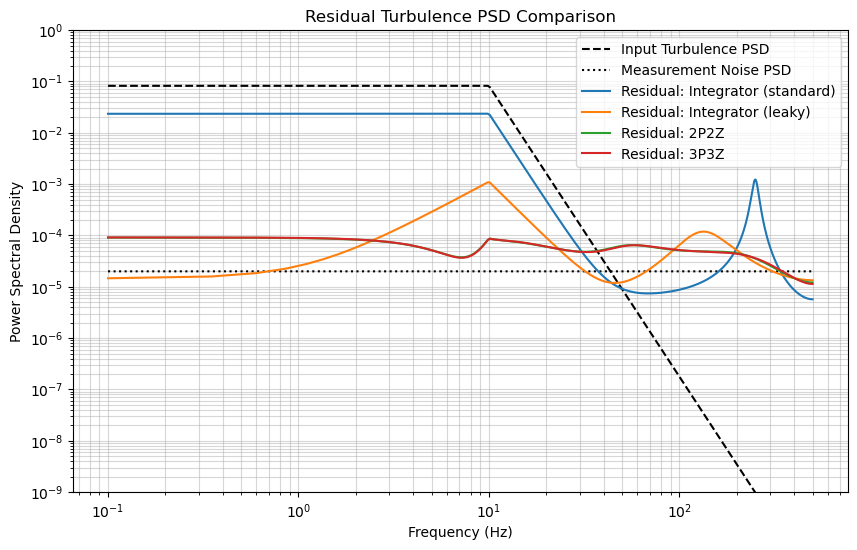

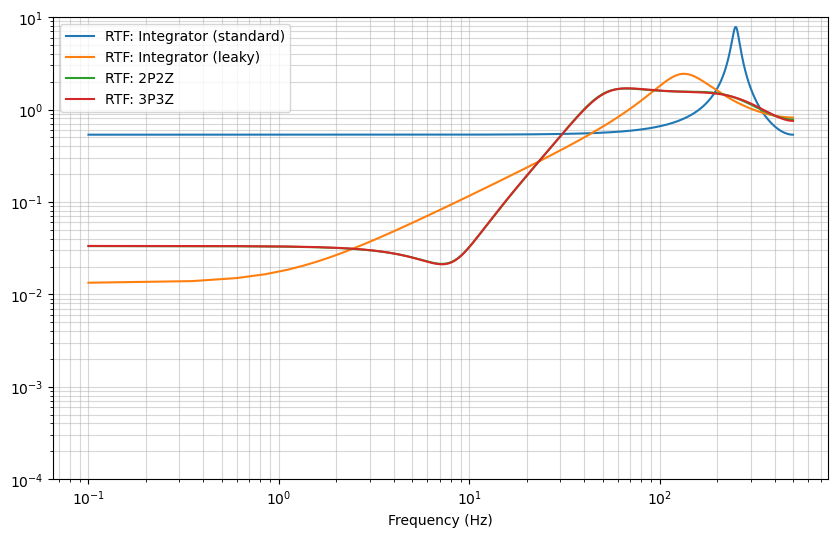

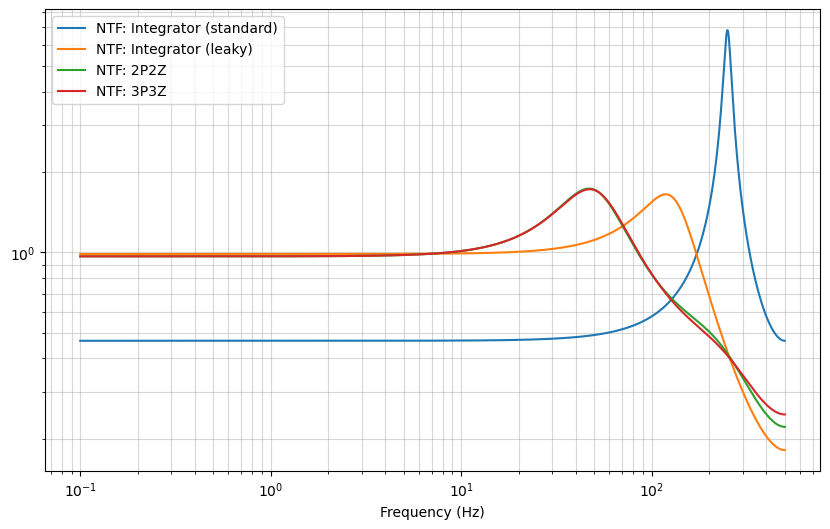

In [ ]:
# System Parameters
D = 8.4
V = 10
n = 2

fs = 1000.0 # Sampling frequency (Hz)
N_delay = 2.0 # Pure fractional delay in steps
fc = 0.3*V/D*(n+1) # Turbulence cutoff frequency (Hz)
snr_db = 40.0 # Signal to noise ratio (dB)

# Frequency grid (exclude 0 initially to avoid integrator div-by-zero, handle DC separately)
f = np.linspace(0.1, fs/2, 2000) #np.logspace(-1, np.log10(fs/2), 2000)
snr_linear = 10**(snr_db / 20)

psd_turb, psd_noise = get_psds(f, fc, fs, snr_linear)

print(f"Plant Delay: {N_delay} steps")
print(f"Optimizing for SNR = {snr_db} dB...\n")

# Define candidates: (num_zeros, num_poles, label)
# order is number of poles and zeros
candidates = [
    # (0, 1, "Integrator (standard)"),
    (1, 1, "Integrator (leaky)"),
    # (1, 2, "Double integrator"),
    (2, 2, "2P2Z"),
    # (2, 3, "2P3Z"),
    (3, 3, "3P3Z"),
]

results = {}

for zeros, poles, label in candidates:
    b_opt, a_opt, final_var = optimize_controller(zeros, poles, f, fs, N_delay, psd_turb, psd_noise)
    var_actual, psd_res, rtf_sq, ntf_sq = evaluate_controller(
        np.concatenate((b_opt, a_opt[1:])), 
        zeros, poles, f, fs, N_delay, psd_turb, psd_noise, return_details=True
    )
    results[label] = {
        'variance': var_actual,
        'psd': psd_res,
        'rtf': rtf_sq,
        'ntf': ntf_sq,
        'b': b_opt,
        'a': a_opt
    }
    print(f"{label}:")
    print(f" Numerator (b): {np.round(b_opt, 4)}")
    print(f" Denominator (a): {np.round(a_opt, 4)}")
    print(f" Residual Variance: {var_actual:.4f}\n")

# Plotting
plt.figure(figsize=(10, 6))
plt.loglog(f, psd_turb, 'k--', label='Input Turbulence PSD')
plt.loglog(f, psd_noise, 'k:', label='Measurement Noise PSD')

for label, data in results.items():
    plt.loglog(f, data['psd'], label=f'Residual: {label}')
    
plt.title('Residual Turbulence PSD Comparison')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.legend()
plt.ylim([1e-9,1])
plt.grid(True, which='both', ls='-', alpha=0.5)

# Plotting
plt.figure(figsize=(10, 6))
for label, data in results.items():
    plt.loglog(f,np.sqrt(data['rtf']), label=f'RTF: {label}')
plt.xlabel('Frequency (Hz)')
plt.legend()
plt.ylim([1e-4,10])
plt.grid(True, which='both', ls='-', alpha=0.5)

plt.figure(figsize=(10, 6))
for label, data in results.items():
    plt.loglog(f,np.sqrt(data['ntf']), label=f'NTF: {label}')
plt.xlabel('Frequency (Hz)')
plt.legend()
plt.grid(True, which='both', ls='-', alpha=0.5)

In [ ]:
alpha = lambda x: np.sin(np.pi*V/(fs*D)*(-(x-n)/2)) / np.sin(np.pi*V/(fs*D)*((x-n)/2)) 

# Substitute z^-1 <- (z^-1 - alpha) / (1 - alpha z^-1)
def define_new_coeffs(num,den,alpha):
    new_num = np.zeros(len(num))
    new_den = np.zeros(len(den))
    a0,a1,a2 = den
    b0,b1,b2 = num
    new_num[0] = 1-alpha*a1+alpha**2*a2
    new_num[1] = -2*alpha+a1*(1+alpha*+2)+2*a2*alpha
    new_num[2] = alpha**2-a1*alpha+a2

    new_den[0] = b0-alpha*b1+alpha**2*b2
    new_den[1] = -2*b0*alpha+b1*(1+alpha*+2)+2*b2*alpha
    new_den[2] = alpha**2*b0-b1*alpha+b2

    return new_num,new_den

num = []
den = []

nn = np.arange(3,30)

L = len(nn)
num_list = np.zeros([L,len(num)])
den_list = np.zeros([L,len(den)])

num_list[0,:] = np.array(num)
den_list[0,:] = np.array(den)

for i in range(L):
    num_list[i+1,:],den_list[i+1,:] = define_new_coeffs(num,den,alpha(nn))

plt.figure()
for i in range(len(num)):
    plt.plot(nn, num_list[:,i]-num[i])
plt.grid()
plt.title('Numerator progression')

plt.figure()
for i in range(len(den)):
    plt.plot(nn, den_list[:,i]-den[i])
plt.grid()
plt.title('Denominator progression')

In [ ]:

# import pandas as pd

# def get_psds(f, fc, fs, snr_linear):
#     # Turbulence (Kolmogorov-ish)
#     psd_turb = np.ones_like(f)
#     mask = f > fc
#     psd_turb[mask] = (f[mask] / fc)**(-17/3)
#     df = f[1] - f[0]
#     psd_turb /= (np.sum(psd_turb) * df) # Normalize
    
#     # White Noise
#     var_noise = 1.0 / snr_linear
#     psd_noise = np.full_like(f, var_noise / (fs / 2))
#     return psd_turb, psd_noise

# def evaluate_controller(params, num_zeros, num_poles, f, fs, N_delay, psd_turb, psd_noise):
#     b = params[:num_zeros+1]
#     a = np.concatenate(([1.0], params[num_poles+1:]))
    
#     w = 2 * np.pi * f / fs
#     _, C = signal.freqz(b, a, worN=w)
#     P = np.exp(-1j * 2 * np.pi * (f / fs) * N_delay)
    
#     H_open = P * C
#     RTF = 1.0 / (1.0 + H_open)
#     NTF = H_open / (1.0 + H_open)
    
#     psd_res = (np.abs(RTF)**2) * psd_turb + (np.abs(NTF)**2) * psd_noise
#     variance = np.sum(psd_res) * (f[1] - f[0])
    
#     # Penalty for instability (Simplified)
#     modulus_margin = np.min(np.abs(1.0 + H_open))
#     penalty = 0
#     if modulus_margin < 0.3: penalty += 1e5 * (0.3 - modulus_margin)
#     if np.any(np.abs(np.roots(a)) > 1.0): penalty += 1e6
        
#     return variance + penalty

# def run_study():
#     delays = [1.5, 2.0, 2.5]
#     sampling_freqs = [500, 1000, 2000]
#     snrs_db = [10, 20, 30, 40]
    
#     # (zeros, poles, label)
#     controllers = [(0,1, "1st Order"), (1,1, "2nd Order"), (2,2, "3rd Order")]
    
#     summary = []

#     for fs in sampling_freqs:
#         f = np.linspace(1e-2, fs/2, 500)
#         for d in delays:
#             for snr_db in snrs_db:
#                 snr_lin = 10**(snr_db/20)
#                 psd_t, psd_n = get_psds(f, 10.0, fs, snr_lin)
                
#                 for nz, np_order, name in controllers:
#                     # Optimize
#                     x0 = np.zeros(nz + np_order + 1)
#                     x0[0] = 0.05 # Small starting gain
                    
#                     res = minimize(evaluate_controller, x0, 
#                                    args=(nz, np_order, f, fs, d, psd_t, psd_n),
#                                    method='Nelder-Mead', options={'maxiter': 1000})
                    
#                     summary.append({
#                         'FS': fs, 'Delay': d, 'SNR_dB': snr_db,
#                         'Controller': name, 'Res_Var': res.fun if res.fun < 1 else 1.0
#                     })
    
#     return pd.DataFrame(summary)

# results_df = run_study()
# # Pivot for easy viewing
# pivot = results_df.pivot_table(index=['FS', 'Delay', 'SNR_dB'], columns='Controller', values='Res_Var')
# print(pivot)
